In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/watspeed_final.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nNull counts:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['Enrolled_Binary'].value_counts())
print("\nClass balance (%):\n", df['Enrolled_Binary'].value_counts(normalize=True).round(3) * 100)

Shape: (2651, 11)

Column names: ['Course Title', 'City', 'Province', 'Country', 'Employer', 'Department', 'Job Title', 'Enrollment Status', 'Program', 'Job Family', 'Enrolled_Binary']

Null counts:
 Course Title            0
City                    0
Province               67
Country                 0
Employer              977
Department           1730
Job Title            1122
Enrollment Status       0
Program                 0
Job Family           1122
Enrolled_Binary         0
dtype: int64

Target distribution:
 Enrolled_Binary
1    2367
0     284
Name: count, dtype: int64

Class balance (%):
 Enrolled_Binary
1    89.3
0    10.7
Name: proportion, dtype: float64


In [2]:
# Features we're keeping
selected_features = ['Course Title', 'Province', 'Country', 'Program', 'Job Family']
target = 'Enrolled_Binary'

# Fill nulls in our selected features
df['Province'] = df['Province'].fillna('Unknown')
df['Job Family'] = df['Job Family'].fillna('Unknown')

# Confirm no nulls remain in our feature set
print("Nulls after filling:")
print(df[selected_features].isnull().sum())

print("\nUnique values per feature:")
for col in selected_features:
    print(f"  {col}: {df[col].nunique()} unique values")

Nulls after filling:
Course Title    0
Province        0
Country         0
Program         0
Job Family      0
dtype: int64

Unique values per feature:
  Course Title: 12 unique values
  Province: 21 unique values
  Country: 31 unique values
  Program: 3 unique values
  Job Family: 491 unique values


In [21]:
# Country: check if simplification makes sense
# The below lines of code were commented out due to confidentiality
"""print("Country distribution (top 10):")
print(df['Country'].value_counts().head(10))
print(f"\nCanada: {(df['Country'] == 'Canada').sum()} records")
print(f"International: {(df['Country'] != 'Canada').sum()} records")"""

'print("Country distribution (top 10):")\nprint(df[\'Country\'].value_counts().head(10))\nprint(f"\nCanada: {(df[\'Country\'] == \'Canada\').sum()} records")\nprint(f"International: {(df[\'Country\'] != \'Canada\').sum()} records")'

In [22]:
# Job Family: cap at top 30, group remainder as 'Other'
# 491 unique values are too high for one-hot encoding.
# Keeping only the top 30 most frequent preserves the meaningful signal
# while avoiding hundreds of near-empty dummy columns that cause overfitting.

# The below lines of code were commented out due to confidentiality

"""top_job_families = df['Job Family'].value_counts().nlargest(30).index
df['Job Family'] = df['Job Family'].apply(
    lambda x: x if x in top_job_families else 'Other'
)

print("Job Family after capping:")
print(f"  Unique values now: {df['Job Family'].nunique()}")
print(f"\nTop 10 Job Families:")
print(df['Job Family'].value_counts().head(10))
print(f"\n'Other' bucket size: {(df['Job Family'] == 'Other').sum()} records")"""

'top_job_families = df[\'Job Family\'].value_counts().nlargest(30).index\ndf[\'Job Family\'] = df[\'Job Family\'].apply(\n    lambda x: x if x in top_job_families else \'Other\'\n)\n\nprint("Job Family after capping:")\nprint(f"  Unique values now: {df[\'Job Family\'].nunique()}")\nprint(f"\nTop 10 Job Families:")\nprint(df[\'Job Family\'].value_counts().head(10))\nprint(f"\n\'Other\' bucket size: {(df[\'Job Family\'] == \'Other\').sum()} records")'

In [23]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Binarize Country
# near-empty columns for countries with 3-5 records — noise, not signal.
df['Is_Canada'] = (df['Country'] == 'Canada').astype(int)

# One-hot encode remaining categoricals
# Using drop_first=True removes one dummy per group to avoid multicollinearity
# (the "dummy variable trap").
encode_cols = ['Course Title', 'Province', 'Program', 'Job Family']

df_encoded = pd.get_dummies(df, columns=encode_cols, drop_first=True)

# Build final feature matrix
# Drop all original/non-feature columns — only keep encoded features + target
drop_cols = ['City', 'Country', 'Employer', 'Department',
             'Job Title', 'Enrollment Status']

df_model = df_encoded.drop(columns=drop_cols)

# Confirm shape and check for any remaining issues
print("Final model dataframe shape:", df_model.shape)
print("\nAny nulls remaining:", df_model.isnull().sum().sum())
print("\nTarget distribution:")
print(df_model['Enrolled_Binary'].value_counts())
# The below lines of code were commented out due to confidentiality
"""print("\nSample of encoded columns (first 10):")
print(df_model.columns[:10].tolist())
print("\nTotal features:", df_model.shape[1] - 1)  # minus target column"""

Final model dataframe shape: (2651, 65)

Any nulls remaining: 0

Target distribution:
Enrolled_Binary
1    2367
0     284
Name: count, dtype: int64


'print("\nSample of encoded columns (first 10):")\nprint(df_model.columns[:10].tolist())\nprint("\nTotal features:", df_model.shape[1] - 1)  # minus target column'

In [6]:
from sklearn.model_selection import train_test_split

# Separate features from target
X = df_model.drop(columns=['Enrolled_Binary'])
y = df_model['Enrolled_Binary']

# Split: 80% train, 20% test
# random_state=42 makes this reproducible — running it again gives same split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print("\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print("\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Training set size: (2120, 64)
Test set size:     (531, 64)

Class balance in training set:
Enrolled_Binary
1    89.3
0    10.7
Name: proportion, dtype: float64

Class balance in test set:
Enrolled_Binary
1    89.3
0    10.7
Name: proportion, dtype: float64


LOGISTIC REGRESSION - BASELINE RESULTS

Classification Report:
              precision    recall  f1-score   support

     Dropped       0.13      0.49      0.21        57
    Enrolled       0.91      0.62      0.74       474

    accuracy                           0.61       531
   macro avg       0.52      0.56      0.47       531
weighted avg       0.83      0.61      0.68       531

AUC-ROC Score: 0.5897


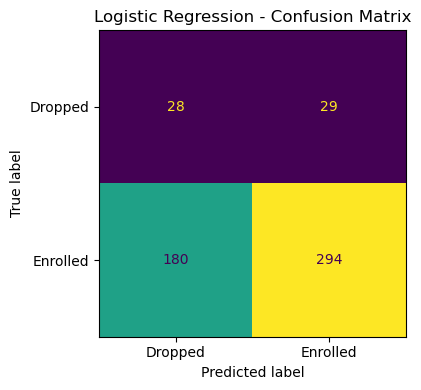

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Train Logistic Regression
# Without it, the model would learn to predict 'Enrolled' almost every time
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Evaluate
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION - BASELINE RESULTS")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Dropped', 'Enrolled']))

print(f"AUC-ROC Score: {roc_auc_score(y_test, lr_probs):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds,
    display_labels=['Dropped', 'Enrolled'],
    colorbar=False, ax=ax
)
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.savefig('../outputs/figures/lr_confusion_matrix.png', dpi=150)
plt.show()

RANDOM FOREST - MAIN MODEL RESULTS

Classification Report:
              precision    recall  f1-score   support

     Dropped       0.12      0.44      0.19        57
    Enrolled       0.90      0.63      0.74       474

    accuracy                           0.61       531
   macro avg       0.51      0.53      0.47       531
weighted avg       0.82      0.61      0.68       531

AUC-ROC Score: 0.5428


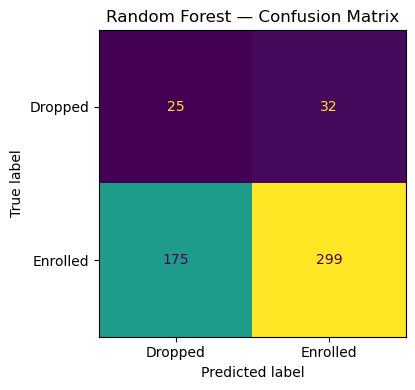

In [8]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Train Random Forest
# n_estimators=300: builds 300 decision trees and combines their votes.
# More trees = more stable predictions, with diminishing returns past ~300.
# class_weight='balanced': same imbalance correction as logistic regression.
# random_state=42: ensures reproducibility.
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # uses all available CPU cores to speed up training
)
rf_model.fit(X_train, y_train)

# Evaluate
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST - MAIN MODEL RESULTS")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['Dropped', 'Enrolled']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, rf_probs):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds,
    display_labels=['Dropped', 'Enrolled'],
    colorbar=False, ax=ax
)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('../outputs/figures/rf_confusion_matrix.png', dpi=150)
plt.show()

Top 20 Most Important Features:
           Feature  Importance
          Course A    0.075310
        Province 1    0.062061
  Job Family_Other    0.058558
Job Family_Unknown    0.055439
        Province 2    0.050135
        Province 3    0.045607
          Course B    0.042236
         Program A    0.029696
          Course C    0.029159


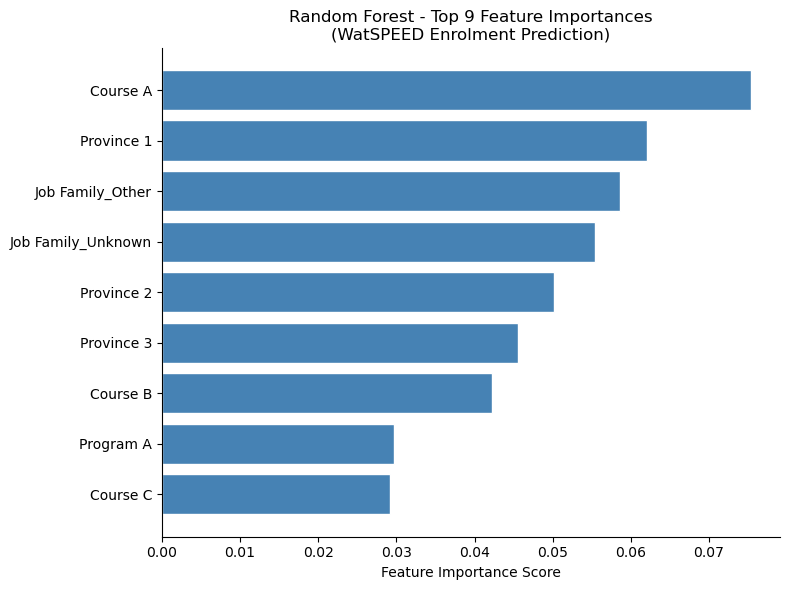

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances from trained Random Forest
# Feature importance = how much each feature reduced prediction error
# averaged across all 300 trees. Higher = more influential.
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Show top 20 only — easier to read and present
# Features have been anonymized for confidentiality
top = importance_df.head(9)

print("Top 20 Most Important Features:")
print(top_portfolio.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    top_portfolio['Feature'][::-1],       # reverse so highest is at top
    top_portfolio['Importance'][::-1],
    color='steelblue',
    edgecolor='white'
)

ax.set_xlabel('Feature Importance Score')
ax.set_title('Random Forest - Top 9 Feature Importances\n(WatSPEED Enrolment Prediction)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/rf_feature_importance.png', dpi=150)
plt.show()

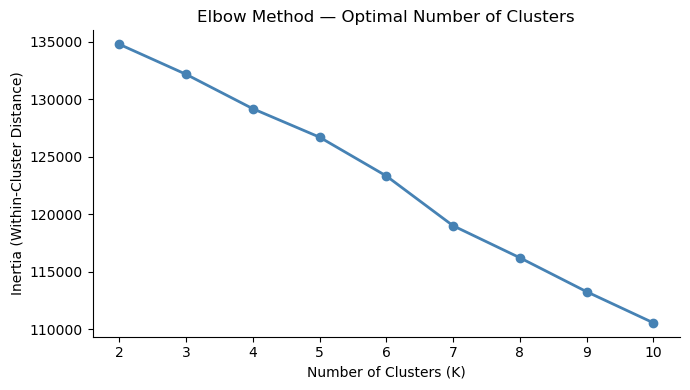

Inertia scores:
  K=2: 134802.5
  K=3: 132188.7
  K=4: 129192.6
  K=5: 126713.5
  K=6: 123337.1
  K=7: 119001.5
  K=8: 116213.8
  K=9: 113257.4
  K=10: 110546.6


['../outputs/models/logistic_regression.pkl']

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib, os
import warnings
warnings.filterwarnings('ignore')

# Select features for clustering
# We're clustering on identity features only — who the learner is,
# not which specific course they took. Course Title has 12 values and
# would dominate the clustering, drowning out occupation and geography.
cluster_cols = [col for col in df_model.columns if
                col.startswith('Province_') or
                col.startswith('Program_') or
                col.startswith('Job Family_') or
                col == 'Is_Canada']

X_cluster = df_model[cluster_cols]

# Scale the features
# K-Means uses distance to measure similarity. Without scaling, a column
# with values 0-100 would dominate over a column with values 0-1,
# even if both are equally meaningful. StandardScaler fixes this by
# converting every column to the same scale (mean=0, std=1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow Method — find the right number of clusters
# Inertia = total distance of every point from its cluster centre.
# Lower inertia = tighter, more defined clusters.
# We look for where improvement starts to flatten — the "elbow."
inertia_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_scores.append(km.inertia_)

# Plot the elbow curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertia_scores, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Distance)')
ax.set_title('Elbow Method — Optimal Number of Clusters')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/kmeans_elbow.png', dpi=150)
plt.show()

print("Inertia scores:")
for k, score in zip(K_range, inertia_scores):
    print(f"  K={k}: {score:.1f}")
os.makedirs('../outputs/models', exist_ok=True)
joblib.dump(rf_model, '../outputs/models/random_forest.pkl')
joblib.dump(lr_model, '../outputs/models/logistic_regression.pkl')